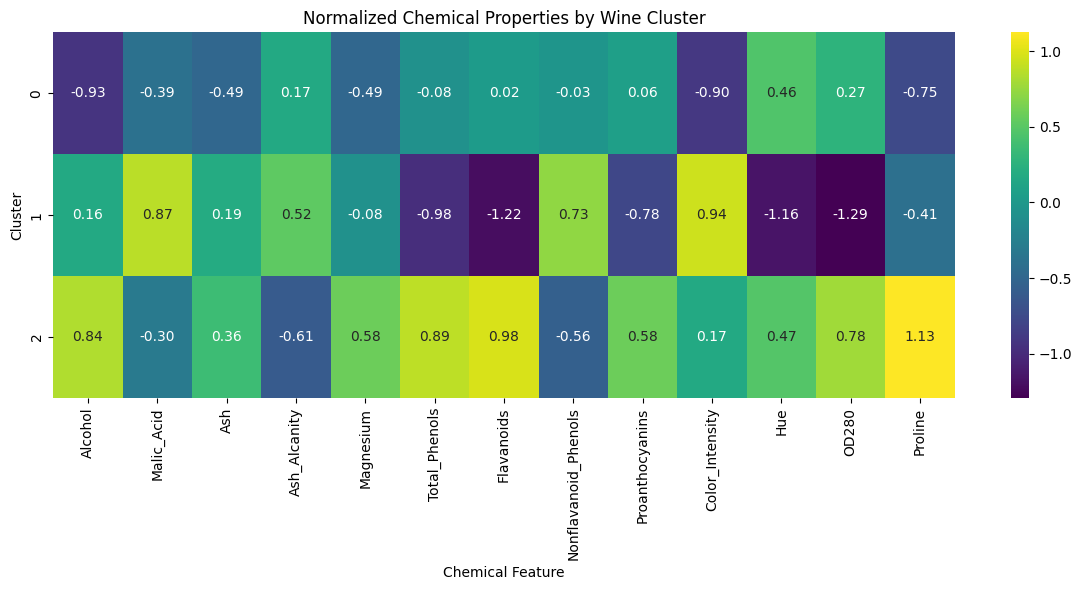

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Read the Wine Clustering dataset from GitHub
url = "https://raw.githubusercontent.com/majidramzi/clustering/refs/heads/main/wine-clustering/wine-clustering.csv"
df = pd.read_csv(url)

# The dataset contains only chemical features
X = df.values

# Feature Scaling is critical here due to different chemical measurement units
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Create a DataFrame for the normalized cluster centers
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns[:-1])

# Plot the Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_centers, annot=True, cmap='viridis', fmt=".2f")
plt.title('Normalized Chemical Properties by Wine Cluster')
plt.ylabel('Cluster')
plt.xlabel('Chemical Feature')
plt.tight_layout()
plt.show()

The K-Means algorithm effectively grouped the wine dataset into three distinct clusters based on 13 chemical properties. Feature scaling was mandatory because measurements like Proline operate on a much larger numerical scale than others like Hue or Ash. The normalized heatmap visually separates the chemical profiles of each segment:
Cluster 0 represents lighter wines characterized by the lowest average alcohol content, minimal color intensity, and low proline levels. Cluster 1 identifies a chemically distinct group with exceptionally low flavanoids and total phenols, yet high malic acid and color intensity. Cluster 2 captures robust wines featuring the highest levels of alcohol, proline, flavanoids, and total phenols. This segmentation proves that unsupervised learning can accurately classify agricultural products purely through raw chemical signatures.